# Shared-observation audit

We construct one emission law `p(X|r)` and reuse it unchanged for static, cyclic, and independent dynamics. Each phase emits a circularly shifted template with random amplitude and offset, small temporal jitter, and noise.

The comparison is deliberately paired: all three conditions reuse exactly the same current and future window banks. Therefore, no marginal statistic of a single window can reveal which dynamics generated the pair; only the temporal coupling between windows changes.

This notebook audits the dataset. The nearest-template decoder uses the ground-truth templates as an observation oracle, not as a learned encoder.

In [1]:
# ruff: noqa: E402, E501
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from sklearn.decomposition import PCA

from koopman_jepa.phase_data import (
    PhaseWindowConfig,
    make_shared_phase_observation_bundle,
    nearest_template_phase_predictions,
    ordered_observation_marginal,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
CONFIG_PATH = ROOT / "configs" / "observation_audit.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw_config = yaml.safe_load(handle)

config = PhaseWindowConfig(**raw_config["emission"])
seed = int(raw_config["seed"])
gates = raw_config["gates"]
bundle = make_shared_phase_observation_bundle(config, seed=seed)
DYNAMICS = ("static", "cyclic", "independent")
LABELS = {"static": "Static", "cyclic": "Cyclic", "independent": "Independent"}

print(json.dumps({"seed": seed, "emission": raw_config["emission"], "gates": gates}, indent=2))

{
  "seed": 20260921,
  "emission": {
    "num_phases": 4,
    "window_length": 128,
    "repeats_per_transition": 64,
    "noise_std": 0.08,
    "amplitude_low": 0.8,
    "amplitude_high": 1.2,
    "offset_std": 0.15,
    "max_shift": 4,
    "pulse_width": 0.055,
    "secondary_offset": 0.1875,
    "secondary_strength": 0.45
  },
  "gates": {
    "minimum_phase_accuracy": 0.99,
    "maximum_decoded_transition_error": 0.01,
    "require_exact_shared_marginals": true,
    "require_distinct_source_future_banks": true
  }
}


In [3]:
def empirical_transition_matrix(current_phases, future_phases, num_phases):
    counts = np.zeros((num_phases, num_phases), dtype=np.float64)
    np.add.at(counts, (current_phases, future_phases), 1.0)
    return counts / counts.sum(axis=1, keepdims=True)

expected_transitions = {
    "static": np.eye(config.num_phases),
    "cyclic": np.roll(np.eye(config.num_phases), 1, axis=1),
    "independent": np.full((config.num_phases, config.num_phases), 1.0 / config.num_phases),
}
reference = bundle.conditions["static"]
reference_current = ordered_observation_marginal(reference, "current")
reference_future = ordered_observation_marginal(reference, "future")
metrics = {}
for dynamics in DYNAMICS:
    condition = bundle.conditions[dynamics]
    ordered_current = ordered_observation_marginal(condition, "current")
    ordered_future = ordered_observation_marginal(condition, "future")
    current_predictions = nearest_template_phase_predictions(condition.current_windows, bundle.templates, config.max_shift)
    future_predictions = nearest_template_phase_predictions(condition.future_windows, bundle.templates, config.max_shift)
    decoded_transition = empirical_transition_matrix(current_predictions, future_predictions, config.num_phases)
    true_transition = empirical_transition_matrix(condition.current_phases, condition.future_phases, config.num_phases)
    metrics[dynamics] = {
        "sample_count": int(len(condition.current_phases)),
        "current_phase_accuracy": float(np.mean(current_predictions == condition.current_phases)),
        "future_phase_accuracy": float(np.mean(future_predictions == condition.future_phases)),
        "current_marginal_max_difference": float(np.max(np.abs(ordered_current - reference_current))),
        "future_marginal_max_difference": float(np.max(np.abs(ordered_future - reference_future))),
        "true_transition_max_error": float(np.max(np.abs(true_transition - expected_transitions[dynamics]))),
        "decoded_transition_max_error": float(np.max(np.abs(decoded_transition - expected_transitions[dynamics]))),
        "decoded_transition": decoded_transition,
    }

max_marginal_difference = max(
    max(result["current_marginal_max_difference"], result["future_marginal_max_difference"])
    for result in metrics.values()
)
minimum_phase_accuracy = min(
    min(result["current_phase_accuracy"], result["future_phase_accuracy"])
    for result in metrics.values()
)
maximum_decoded_transition_error = max(result["decoded_transition_max_error"] for result in metrics.values())
source_future_mean_absolute_difference = float(np.mean(np.abs(reference_current - reference_future)))
source_future_banks_are_distinct = not np.array_equal(reference_current, reference_future)

serializable_metrics = {
    dynamics: {key: value for key, value in result.items() if key != "decoded_transition"}
    for dynamics, result in metrics.items()
}
print(json.dumps(serializable_metrics, indent=2))

{
  "static": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  },
  "cyclic": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  },
  "independent": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  }
}


In [4]:
exact_marginals_pass = (
    max_marginal_difference == 0.0
    if gates["require_exact_shared_marginals"]
    else True
)
phase_accuracy_pass = minimum_phase_accuracy >= gates["minimum_phase_accuracy"]
transition_pass = maximum_decoded_transition_error <= gates["maximum_decoded_transition_error"]
distinct_banks_pass = (
    source_future_banks_are_distinct
    if gates["require_distinct_source_future_banks"]
    else True
)
observation_audit_passed = bool(
    exact_marginals_pass and phase_accuracy_pass and transition_pass and distinct_banks_pass
)
audit_gate = {
    "exact_shared_marginals": bool(exact_marginals_pass),
    "phase_identifiable": bool(phase_accuracy_pass),
    "decoded_temporal_laws": bool(transition_pass),
    "distinct_source_future_banks": bool(distinct_banks_pass),
    "observation_audit_passed": observation_audit_passed,
}
print(json.dumps(audit_gate, indent=2))
assert observation_audit_passed

{
  "exact_shared_marginals": true,
  "phase_identifiable": true,
  "decoded_temporal_laws": true,
  "distinct_source_future_banks": true,
  "observation_audit_passed": true
}


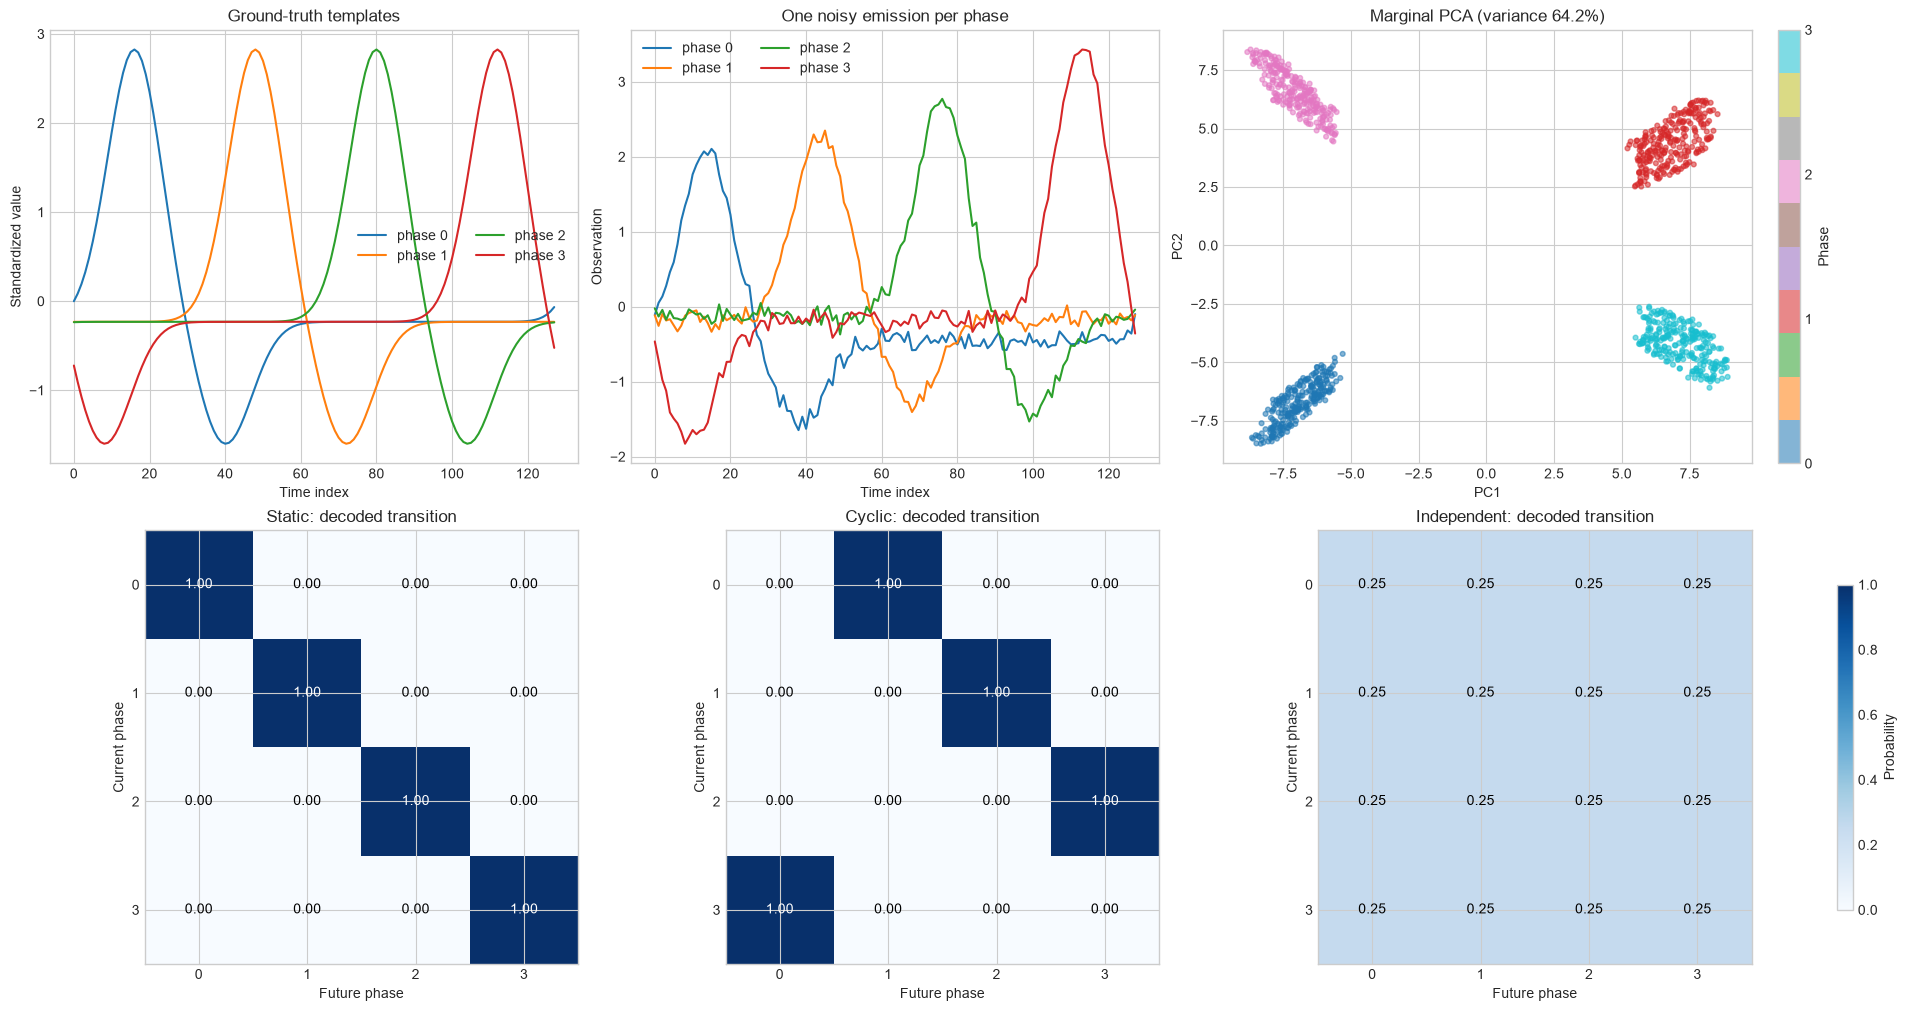

## Result analysis

- Dataset audit: **PASS**.
- Pairs per condition: **1024**; observations per phase and marginal: **256**.
- Maximum difference between paired observable marginals: **0.00e+00**.
- Worst phase-oracle decoder accuracy: **100.00%**.
- Maximum decoded-transition error: **0.00e+00**.
- Mean absolute difference between source and target banks: **0.341**.

All three conditions contain exactly the same windows when sorted by phase and emission identifier. By construction, a classifier observing one window can recover its phase but cannot tell whether it belongs to the static, cyclic, or independent condition. That information appears only in the temporal pair.

The lower matrices recover all three laws after decoding the windows: identity, cyclic advance, and uniform transition. Amplitude, offset, jitter, and noise therefore preserve the phase signal in this controlled setting.

Exact bank reuse is an intentional paired control, not an assumption about real data. Separate seeds prevent realization sharing across splits. This audit validates the generator; by itself, it does not show that JEPA learns a Koopman subspace.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
time = np.arange(config.window_length)
for phase, template in enumerate(bundle.templates):
    axes[0, 0].plot(time, template, label=f"phase {phase}")
axes[0, 0].set(title="Ground-truth templates", xlabel="Time index", ylabel="Standardized value")
axes[0, 0].legend(ncol=2)

condition = bundle.conditions["independent"]
for phase in range(config.num_phases):
    index = int(np.flatnonzero(condition.current_phases == phase)[0])
    axes[0, 1].plot(time, condition.current_windows[index, 0], label=f"phase {phase}")
axes[0, 1].set(title="One noisy emission per phase", xlabel="Time index", ylabel="Observation")
axes[0, 1].legend(ncol=2)

pca = PCA(n_components=2)
projection = pca.fit_transform(reference_current[:, 0, :])
ordered_phases = np.repeat(np.arange(config.num_phases), config.num_phases * config.repeats_per_transition)
scatter = axes[0, 2].scatter(projection[:, 0], projection[:, 1], c=ordered_phases, cmap="tab10", s=12, alpha=0.55)
axes[0, 2].set(title=f"Marginal PCA (variance {pca.explained_variance_ratio_.sum():.1%})", xlabel="PC1", ylabel="PC2")
fig.colorbar(scatter, ax=axes[0, 2], ticks=np.arange(config.num_phases), label="Phase")

for axis, dynamics in zip(axes[1], DYNAMICS, strict=True):
    image = axis.imshow(metrics[dynamics]["decoded_transition"], cmap="Blues", vmin=0, vmax=1)
    for row in range(config.num_phases):
        for column in range(config.num_phases):
            value = metrics[dynamics]["decoded_transition"][row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black")
    axis.set(title=f"{LABELS[dynamics]}: decoded transition", xlabel="Future phase", ylabel="Current phase", xticks=range(config.num_phases), yticks=range(config.num_phases))
fig.colorbar(image, ax=axes[1].tolist(), shrink=0.75, label="Probability")
plt.show()

display(Markdown(f"""## Result analysis

- Dataset audit: **{'PASS' if observation_audit_passed else 'FAIL'}**.
- Pairs per condition: **{metrics['static']['sample_count']}**; observations per phase and marginal: **{config.num_phases * config.repeats_per_transition}**.
- Maximum difference between paired observable marginals: **{max_marginal_difference:.2e}**.
- Worst phase-oracle decoder accuracy: **{minimum_phase_accuracy:.2%}**.
- Maximum decoded-transition error: **{maximum_decoded_transition_error:.2e}**.
- Mean absolute difference between source and target banks: **{source_future_mean_absolute_difference:.3f}**.

All three conditions contain exactly the same windows when sorted by phase and emission identifier. By construction, a classifier observing one window can recover its phase but cannot tell whether it belongs to the static, cyclic, or independent condition. That information appears only in the temporal pair.

The lower matrices recover all three laws after decoding the windows: identity, cyclic advance, and uniform transition. Amplitude, offset, jitter, and noise therefore preserve the phase signal in this controlled setting.

Exact bank reuse is an intentional paired control, not an assumption about real data. Separate seeds prevent realization sharing across splits. This audit validates the generator; by itself, it does not show that JEPA learns a Koopman subspace.
"""))